<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK6_study_0410.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ch4. 7, 8, 11 (p.244 ~ 267, 295 ~ 306)
##4.7 LightGBM
- 장점
  - XGBoost보다 학습에 걸리는 시간, 메모리 사용량이 훨씬 적음.
  - 카테고리형 피처 자동변환과 최적 분할
- 리프 중심 트리 분할(Leaf Wise)
  - 트리 균형 맞추지 않고, 최대 손실값을 가지는 리프 노드를 지속적으로 분할.
  - 트리 깊이가 깊어지고 비대칭적 규칙 트리 생성.

- 균형 트리 분할과는 다름.
  - 균형 잡힌 트리를 유지하며 분할 -> 트리의 깊이 최소화
  - 오버피팅에 강한 구조
  - 트리의 균형을

In [1]:
!pip install scikit-learn==1.2.2
!pip install xgboost==1.7.6
!pip install lightgbm==3.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 17.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn: filename=scikit_learn-1.2.2-cp312-cp312-linux_x86_64.whl size=9452405 sha256=5f5191c4654b29dbdabf1f6f160ea9ed19129f84850a1c1b857ba7f3ca03f130
  Stored in directory: /root/.cache/pip/wheels/24/f8/77/ae90c181b806f450a6fec8c8f794594e7c92fa79d7ca27e656
Successfully built scikit-learn
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
mlxtend 0.23.4 require

In [2]:
!pip install "numpy<2.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-pytho

In [1]:
import lightgbm
from lightgbm import LGBMClassifier

###LightGBM 하이퍼 파라미터
####주요 파라미터
- num_iterations [default = 100]
  - 반복 수행하려는 트리의 개수 지정
  - 크게 지정할수록 예측 성능이 높아질 수 있으나, 너무 크게 지정하면 과적합으로 성능 저하
  - n_estimators로 이름 변경 가능
- learning_rate [default = 0.1]
  - 0과 1 사이의 값을 지정.
  - 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률 값
  - n_estimators를 크게 하고 learning_rate를 작게 해서 예측 성능을 향상시킬 수 있음.
- max_depth [default = -1]
  - 트리 기반 알고리즘의 max_depth와 같음.
  - 0보다 작은 값을 지정하면 깊이에 제한이 없음.
- min_data_in_leaf [default = 20]
  - 최종 결정 클래스인 리프 노드가 되기 위해 최소한으로 필요한 레코드 수
  - 과적합 제어
  - 결정트리의 min_samples_leaf와 같은 파라미터.  min_child_samples로 이름 변경됨.
- num_leaves [default = 31]
  - 하나의 트리가 가질 수 있는 최대 리프 개수
- boosting [default = gbdt]
  - 부스팅의 트리를 생성하는 알고리즘을 기술
  - gbdt: 일반적인 그래디언트 부스팅 결정 트리
  - rt: 랜덤 포레스트
- bagging_fraction [default = 1.0]
  - 트리가 커져서 과적합되는 것을 제어하기 위해 데이터를 샘플링하는 비율을 지정
- feature_fraction [default = 1.0]
  - 개별 트리를 학습할 때마다 무작위로 선택하는 피처의 비율
  - 과적합을 막기 위해 사용
  - colsample_bytree로 변경됨.
- lambda_l2 [default = 0.0]
  - L2 regulation 제어를 위한 값
  - 피처 개수가 많을 경우 적용을 검토하여 값이 클수록 과적합 감소 효과가 있음.
  - reg_lambda로 변경됨.
- lambda_l1 [default = 0.0]
  - L1 regulation 제어를 위한 값
  - L2와 마찬가지로 과적합 제어를 위한 것
  - reg_alpha로 변경됨.

####Learning Task 파라미터
- objective
  - 최솟값을 가져야 할 손실함수를 정의
  - 애플리케이션 유형, 즉 회귀, 다중 클래스 분류, 이진 분류

###하이퍼 파리미터 튜닝 방안
- num_leaves의 개수를 중심으로 min_child_samples(min_data_in_leaf), max_depth를 함께 조정하면서 모델의 복잡도를 줄이는 것
- learning_rate를 작게 하면서 n_estimators를 크게 하는 것
  - n_estimators를 너무 크게 하는 것은 과적합 우려
- regularization 적용
  - reg_lambda, reg_alpha
  - 과적합 제어
- colsample_bytree, subsample 적용
  - 학습 데이터에 사용할 피처의 개수나 데이터 샘플링 레코드 개수를 줄이기 위해


###파이썬 래퍼 LightGBM과 사이킷런 래퍼 XGBoost, LightGBM 하이퍼 파라미터 비교
| 파이썬 래퍼 LightGBM | 사이킷런 래퍼 LightGBM | 사이킷런 래퍼 XGBoost |
| :--- | :--- | :--- |
| `num_iterations` | `n_estimators` | `n_estimators` |
| `learning_rate` | `learning_rate` | `learning_rate` |
| `max_depth` | `max_depth` | `max_depth` |
| `min_data_in_leaf` | `min_child_samples` | `N/A` |
| `bagging_fraction` | `subsample` | `subsample` |
| `feature_fraction` | `colsample_bytree` | `colsample_bytree` |
| `lambda_l2` | `reg_lambda` | `reg_lambda` |
| `lambda_l1` | `reg_alpha` | `reg_alpha` |
| `early_stopping_round` | `early_stopping_rounds` | `early_stopping_rounds` |
| `num_leaves` | `num_leaves` | `N/A` |
| `min_sum_hessian_in_leaf` | `min_child_weight` | `min_child_weight` |

In [2]:
# LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier
from lightgbm import early_stopping, log_evaluation

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']=dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정.
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능
evals=[(X_tr, y_tr),(X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr, callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=10)],
                 eval_metric="logloss", eval_set=evals)
preds=lgbm_wrapper.predict(X_test)
pred_proba=lgbm_wrapper.predict_proba(X_test)[:,1]

Training until validation scores don't improve for 50 rounds
[10]	training's binary_logloss: 0.386526	valid_1's binary_logloss: 0.461267
[20]	training's binary_logloss: 0.246443	valid_1's binary_logloss: 0.362062
[30]	training's binary_logloss: 0.167198	valid_1's binary_logloss: 0.310105
[40]	training's binary_logloss: 0.115054	valid_1's binary_logloss: 0.282853
[50]	training's binary_logloss: 0.0789991	valid_1's binary_logloss: 0.267587
[60]	training's binary_logloss: 0.0550801	valid_1's binary_logloss: 0.260746
[70]	training's binary_logloss: 0.0383095	valid_1's binary_logloss: 0.267484
[80]	training's binary_logloss: 0.0264668	valid_1's binary_logloss: 0.270523
[90]	training's binary_logloss: 0.0183664	valid_1's binary_logloss: 0.276485
[100]	training's binary_logloss: 0.0126961	valid_1's binary_logloss: 0.279265
[110]	training's binary_logloss: 0.00882581	valid_1's binary_logloss: 0.282152
Early stopping, best iteration is:
[61]	training's binary_logloss: 0.0532381	valid_1's binary

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

def get_clf_eval(y_test, pred, pred_proba):
  confusion=confusion_matrix(y_test, pred)
  accuracy=accuracy_score(y_test, pred)
  precision=precision_score(y_test, pred)
  recall=recall_score(y_test, pred)
  f1=f1_score(y_test, pred)

  #ROC-AUC 추가
  roc_auc=roc_auc_score(y_test, pred_proba)
  print('오차행렬')
  print(confusion)

  #ROC-AUC print 추가
  print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall,f1,roc_auc))

In [4]:
get_clf_eval(y_test, preds, pred_proba)

오차행렬
[[34  3]
 [ 2 75]]
정확도:0.9561, 정밀도:0.9615, 재현율0.9740, F1:0.9677, AUC:0.9877


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

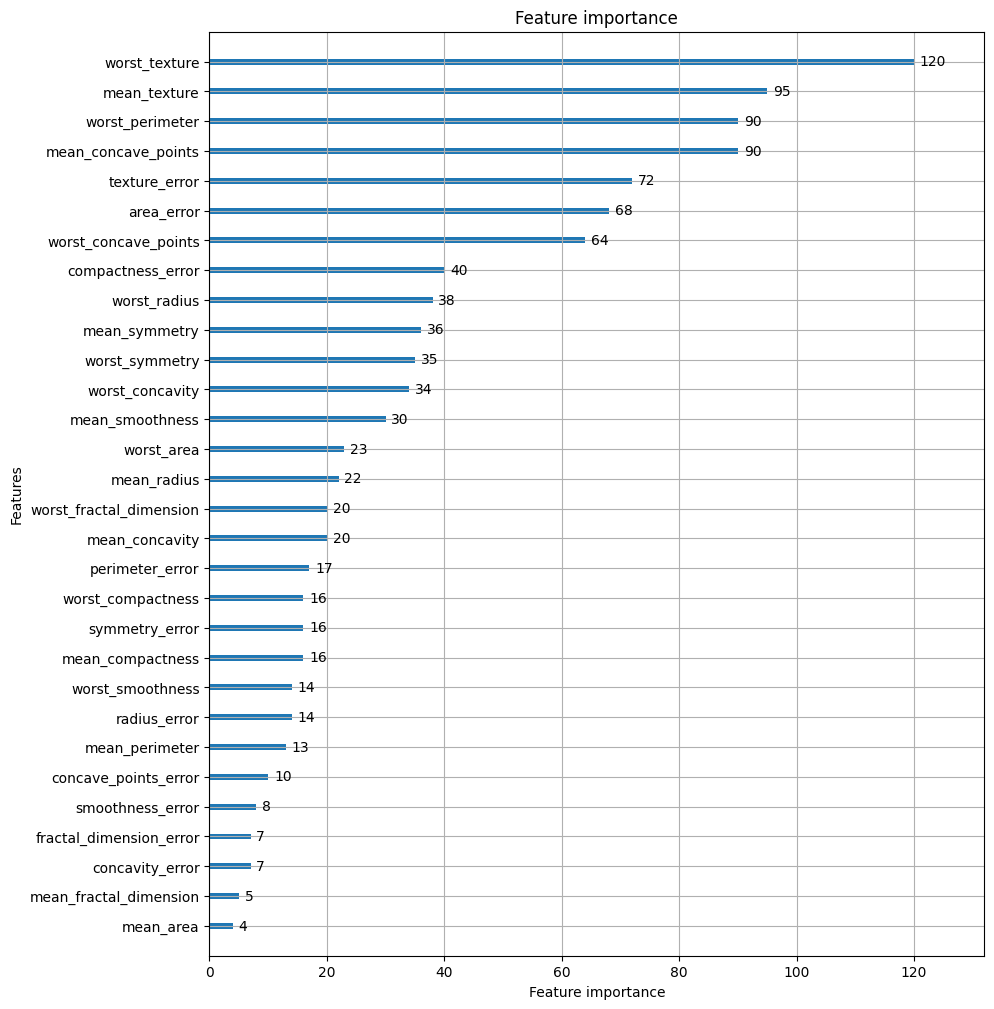

In [5]:
# plot_importance()를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(lgbm_wrapper, ax=ax)

##4.8 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝
- 하이퍼 파라미터 개수가 많아 Grid Search 방식으로 최적 하이퍼 파라미터를 찾으려면 많은 시간 소모.
- 하이퍼 파리미터 개수를 줄이거나 개별 하이퍼 파라미터의 범위를 줄여야 함.
=> Grid Search보다 베이지안 최적화 기법 적용

In [6]:
# 5 x 4 x 5 x 5 x 4 x 3 = 6000회에 걸처 반복적으로 학습과 평가 수행
params = {
    'max_depth': [10, 20, 30, 40, 50], 'num_leaves': [35, 45, 55, 65],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9], 'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [10, 20, 30, 40], 'reg_alpha': [0.01, 0.05, 0.1]
}

###베이지안 최적화 개요
- 목적 함수 식을 제대로 알 수 없는 블랙 박스 형태의 함수에서 최대 또는 최소 함수 반환 값을 만드는 최적 입력값을 가능한 적은 시도를 통해 빠르고 효과적으로 찾아주는 방식
  - 예: f(x,y) = 2x - 3y => f(x,y)의 반환 값을 최대/최소로 하는 x, y값 찾기
- 베이지안 최적화
  - 새로운 데이터를 입력받았을 때 최적 함수를 예측하는 사후 모델을 개선해 나가면서 최적 함수 모델을 만들어 냄.
  - 대체 모델(Surrogate Model)
    - 획득 함수로부터 최적 함수를 예측할 수 있는 입력값을 추천 받은 뒤 최적 함수 모델 개선
  - 획득 함수(Acquisition Function)
    - 개선된 대체 모델을 기반으로 최적 입력값 계산



---


[베이지안 최적화 단계]

**Step1 ) 최초에는 랜덤하게 하이퍼 파라미터들을 샘플링하고 성능 결과를 관측한다.**
- 검은색 원: 특정 하이퍼 파라미터가 입력되었을 때 관측된 성능 지표 결과값
- 주황색 사선: 찾아야 할 목표 최적함수
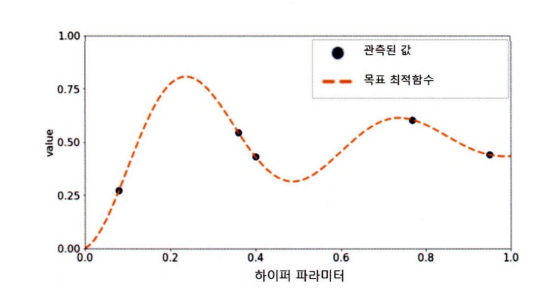

**Step 2 ) 관측된 값을 가반으로 대체 모델은 최적 함수를 추정**
- 파란색 실선: 대체 모델이 추정한 최적 함수
- 옅은 파란색 영역: 예측된 함수의 신뢰 구간. 추정된 함수의 결과값 오류 편차. 추정 함수의 불확실성.
- 최적 관측값: y축 value에서 가장 높은 값을 가질 때의 하이퍼 파라미터
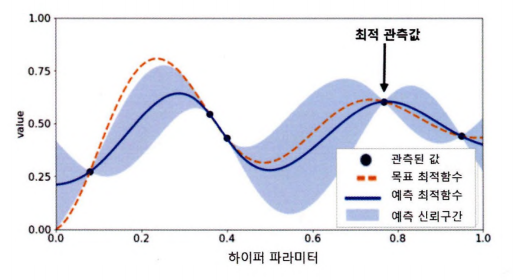

**Step 3 ) 추정된 최적 함수를 기반으로 획득 함수는 다음으로 관측할 하이퍼 파라미터 값을 계산**
- 이전의 최적 관측값보다 더 큰 최댓값을 가질 가능성이 높은 지점을 찾아서 다음에 관측할 하이퍼 파라미터 대체 모델에 전달
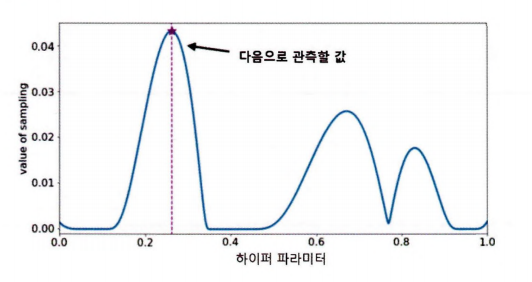

**Step 4 ) 획득 함수로부터 전달된 하이퍼 파라미터를 수행하여 관측된 값을 기반으로 대체 모델은 갱신되어 다시 최적함수를 예측 추정함.**
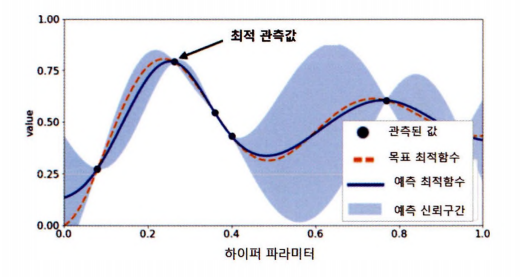

###HyperOpt 사용하기
- 베이지안 최적화를 머신러닝 모델의 하이퍼 파라미터 튜닝에 적용할 수 있는 파이썬 패키지
- 목적 함수 반환 값의 최댓값이 아닌 최솟값을 가지는 최적 입력값을 유추

In [7]:
!pip install hyperopt

####입력 변수명과 입력값의 검색 공간 설정

In [8]:
from hyperopt import hp

# -10 ~ 10까지 1간격을 가지는 입력 변수 x와 -15 ~ 15까지 1간격으로 입력 변수 y 설정.
search_space = {'x': hp.quniform('x', -10, 10, 1), 'y': hp.quniform('y', -15, 15, 1)}

[입력값의 검색 공간을 제공하는 함수]
- hp.quniform(label, low, high, q)
  - label로 지정된 입력값 변수 검색 공간을 최솟값 low에서 최댓값 high까지 q의 간격을 가지고 설정.
- hp.uniform(label, low, high)
  - 최솟값 low에서 최댓값 high까지 정규 분포 형태의 검색 공간 설정
- hp.radint(label, upper)
  - 0부터 최댓값 upper까지 random한 정숫값으로 검색 공간 설정
- hp.loguniform(label, low, high)
  - exp(uniform(low, high)값을 반환
  - 반환 값의 log 변환된 값은 정규 분포 형태를 가지는 검색 공간 설정.
- hp.choice(label, options)
  - 검색 값이 문자열 또는 문자열과 숫자값이 섞여 있을 경우 설정
  - Options는 리스트나 튜플 형태로 제공됨.
  - hp.choice('tree_criterion', ['gini', 'entropy'])과 같이 설정하면 입력 변수 tree_criterion의 값을 'gini', 'entropy'로 설정하여 입력함.

####목적 함수의 설정
- 반드시 변숫값과 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환하는 구조로 만들어져야 함.
- 숫자형 단일값 이외에도 딕셔너리 형태로 반환 가능
- loss와 status 키 값을 설정해서 반환해야 함.

In [9]:
from hyperopt import STATUS_OK

# 목적 함수를 생성. 변숫값과 변수 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환
def objective_func(search_space):
  x = search_space['x']
  y = search_space['y']
  retval = x**2 - 20*y

  return retval

[fmin() 함수의 주요 인자]
- fn
  - 위에서 생성한 objective_func와 같은 목적 함수
- space
  - 위에서 생성한 search_space와 같은 검색 공간 딕셔너리
- algo
  - 베이지안 최적화 적용 알고리즘
  - 기본적으로 tpe.suggest이며 HyperOpt의 기본 최적화 알고리즘인 TPE(Tree of Parzen Estimator)를 의미함.
- max_evals
  - 최적 입력값을 찾기 위한 입력값 시도 횟수
- trials
  - 최적 입력값을 찾기 위해 시도한 입력값 및 해당 입력값의 목적 함수 반환값 결과를 저장하는 데 사용
  - Trials 클래스를 객체로 생성한 변수명을 입력함.
- rstate
  - fmin()을 수행할 때마다 동일한 결과값을 가질 수 있도록 설정하는 랜덤 시드 값

####목적함수의 반환 최솟값을 가지는 최적 입력값을 유추

In [10]:
from hyperopt import fmin, tpe, Trials
# 입력 결과값을 저장한 Trials 객체값 생성.
trial_val = Trials()

# 목적 함수의 최솟값을 반환하는 최적 입력 변수값을 5번의 입력값 시도(max_evals=5)로 찾아냄.
best_01 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_01)

100%|██████████| 5/5 [00:00<00:00, 399.31trial/s, best loss: -224.0]
best: {'x': -4.0, 'y': 12.0}


=> x의 공간 -10 ~ 10, y의 공간 -15 ~ 15에서 목적 함수의 반환값을 x ** 2 - 20 * y로 설정했으므로, x는 0에 가까울수록 y는 15에 가까울수록 반환값이 최소로 근사

In [11]:
trial_val = Trials()

# max_evals를 20회로 늘려서 재테스트
best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=20,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_02)

100%|██████████| 20/20 [00:00<00:00, 459.53trial/s, best loss: -296.0]
best: {'x': 2.0, 'y': 15.0}


In [12]:
# fmin()에 인자로 들어가는 Trials 객체의 result 속성에 파이썬 리스트로 목적 함수 반환값들이 저장됨
# 리스트 내부의 개별 원소는 {'loss': 함수 반환값, 'status': 반환 상태값}와 같은 딕셔너리임.
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


result의 속성은 loss와 status를 키값으로 가지는 20개의 딕셔너리를 개별 원소를 가지는 리스트로 구성되어 있음.

In [13]:
# Trials 객체의 vals 속성에 {'입력변수명': 개별 수행 시마다 입력된 값 리스트} 형태로 저장됨.
print(trial_val.vals)

{'x': [-6.0, -4.0, 4.0, -4.0, 9.0, 2.0, 10.0, -9.0, -8.0, -0.0, -0.0, 1.0, 9.0, 6.0, 9.0, 2.0, -2.0, -4.0, 7.0, -0.0], 'y': [5.0, 10.0, -2.0, 12.0, 1.0, 15.0, 7.0, -10.0, 0.0, -5.0, -3.0, 2.0, 4.0, 10.0, 3.0, 3.0, -14.0, -8.0, 11.0, -0.0]}


In [14]:
import pandas as pd

# results에서 loss 키값에 해당하는 밸류들을 추출하여 list로 생성.
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

# DataFrame으로 생성.
result_df = pd.DataFrame({'x': trial_val.vals['x'], 'y': trial_val.vals['y'], 'losses': losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


###HyperOpt를 이용한 XGBoost하이퍼 파라미터 최적화
- 적용해야 할 하이퍼 파라미터와 검색 공간 설정 -> 목적 함수에서 XGBoost를 학습 -> 예측 성능 결과를 반환값으로 설정 -> fmin() 함수에서 목적 함수를 하이퍼 파라미터 검색 공간의 입력값들을 사용하여 최적의 예측 성능 결과를 반환하는 최적 입력값들을 결정

- 유의점
  - 특정 하이퍼 파라미터들은 정숫값만 입력을 받는데 HyperOpt는 입력값과 반환값이 모두 실수형이기 때문에 형변환 필수
  - 성능값이 클수록 좋은 성능 지표일 경우 -1을 곱해줘야 함.

In [15]:
# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size = 0.2, random_state=156)

# 앞에서 추출한 학습 데이터를 다시 학습과 검증 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

In [16]:
from hyperopt import hp

# max_depth는 5에서 20까지 1간격으로, min_child_weight는 1에서 2까지 1간격으로
# colsample_bytree는 0.5에서 1 사이, learning_rate는 0.01에서 0.2 사이 정규 분포된 값으로 검색.
xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1)
}

- cross_val_score()를 XGBoost나 LightGBM에 적용할 경우 early stopping이 지원되지 않음
- 조기 중단을 위해서는 KFold로 학습과 검증용 데이터 세트를 만들어서 직접 교차 검증을 수행해야 함.


In [17]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

# fmin()에서 입력된 search_space 값으로 입력된 모든 값은 실수형임.
# XGBClassifier의 정수형 하이퍼 파라미터는 정수형 변환을 해줘야 함.
# 정확도는 높을수록 더 좋은 수치임. -1 * 정확도를 곱해서 큰 정확도 값일수록 최소가 되도록 변환
def objective_func(search_space):
  # 수행 시간 절약을 위해 nestimators는 100으로 축소
  xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                          min_child_weight=int(search_space['min_child_weight']),
                          learning_rate=search_space['learning_rate'],
                          colsample_bytree=search_space['colsample_bytree'],
                          eval_metric='logloss')
  accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

  # accuracy는 cv=3 개수만큼 roc-auc 결과를 리스트로 가짐. 이를 평균해서 반환하되 -1을 곱함.
  return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK}

In [19]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50, # 최대 반복 횟수를 지정합니다.
            trials=trial_val, rstate=np.random.default_rng(seed=9))
print('best:', best)

100%|██████████| 50/50 [00:42<00:00,  1.17trial/s, best loss: -0.9670616939700244]
best: {'colsample_bytree': 0.9599446282177103, 'learning_rate': 0.15480405522751015, 'max_depth': 6.0, 'min_child_weight': 2.0}


In [20]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.95994, learning_rate:0.1548, max_depth:6, min_child_weight:2


In [21]:
xgb_wrapper = XGBClassifier(n_estimators=400,
                            learning_rate=round(best['learning_rate'], 5),
                            max_depth=int(best['max_depth']),
                            min_child_weight=int(best['min_child_weight']),
                            colsample_bytree=round(best['colsample_bytree'], 5)
)

evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds=50, eval_metric='logloss',
                eval_set=evals, verbose=True)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test, preds, pred_proba)

[0]	validation_0-logloss:0.56834	validation_1-logloss:0.60660
[1]	validation_0-logloss:0.47552	validation_1-logloss:0.54538
[2]	validation_0-logloss:0.40208	validation_1-logloss:0.48735
[3]	validation_0-logloss:0.34468	validation_1-logloss:0.45698
[4]	validation_0-logloss:0.29775	validation_1-logloss:0.41729
[5]	validation_0-logloss:0.26004	validation_1-logloss:0.39167
[6]	validation_0-logloss:0.22681	validation_1-logloss:0.36682
[7]	validation_0-logloss:0.20096	validation_1-logloss:0.34593
[8]	validation_0-logloss:0.17762	validation_1-logloss:0.33030
[9]	validation_0-logloss:0.15762	validation_1-logloss:0.31918
[10]	validation_0-logloss:0.14233	validation_1-logloss:0.30772
[11]	validation_0-logloss:0.12769	validation_1-logloss:0.30104


/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:835: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[12]	validation_0-logloss:0.11566	validation_1-logloss:0.29621
[13]	validation_0-logloss:0.10479	validation_1-logloss:0.29157
[14]	validation_0-logloss:0.09640	validation_1-logloss:0.28495
[15]	validation_0-logloss:0.08707	validation_1-logloss:0.28055
[16]	validation_0-logloss:0.08067	validation_1-logloss:0.27775
[17]	validation_0-logloss:0.07468	validation_1-logloss:0.27470
[18]	validation_0-logloss:0.06971	validation_1-logloss:0.27426
[19]	validation_0-logloss:0.06376	validation_1-logloss:0.27298
[20]	validation_0-logloss:0.05900	validation_1-logloss:0.27030
[21]	validation_0-logloss:0.05483	validation_1-logloss:0.26467
[22]	validation_0-logloss:0.05115	validation_1-logloss:0.26722
[23]	validation_0-logloss:0.04855	validation_1-logloss:0.26117
[24]	validation_0-logloss:0.04630	validation_1-logloss:0.26024
[25]	validation_0-logloss:0.04365	validation_1-logloss:0.26456
[26]	validation_0-logloss:0.04105	validation_1-logloss:0.26599
[27]	validation_0-logloss:0.03936	validation_1-logloss:

##4.11 스태킹 앙상블
- 개별적인 여러 알고리즘을 서로 결합해 예측 결과를 도출
  - 배깅, 부스팅과 공통점
- 개별 알고리즘으로 예측한 데이터를 기반으로 다시 예측을 수행
  - 차이점
  - 개별 알고리즘의 예측 결과와 데이터 세트를 최종적인 메타 데이터 세트로 만들어
  - 별도의 ML 알고리즘으로 최종 학습을 수행하고
  - 테스트 데이터를 기반으로 다시 최종 예측을 수행

- 두 종류의 모델 필요
  - 개별적인 기반 모델
  - 개별기반모델의 예측 데이터를 학습 데이터로 만들어서 학습하는 최종 메타 모델

=> 여러 개별 모델의 예측 데이터를 각각 스태킹 형태로 결합해 최종 메타 모델의 학습용 피처 데이터 세트와 테스트용 피처 데이터 세트를 만드는 것

=> 여러 개의 모델에 대한 예측값을 합한 후 이에 대한 예측을 다시 수행

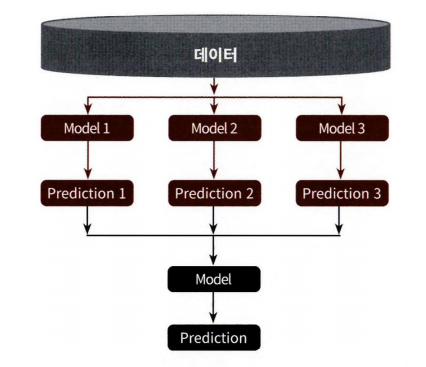

###기본 스태킹 모델

In [29]:
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer_data = load_breast_cancer()

X_data = cancer_data.data
y_label = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.2, random_state=0)

In [30]:
# 개별 ML 모델 생성
knn_clf = KNeighborsClassifier(n_neighbors=4)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf = DecisionTreeClassifier()
ada_clf = AdaBoostClassifier(n_estimators=100)

# 스태킹으로 만들어진 데이터 세트를 학습, 예측할 최종 모델
lr_final = LogisticRegression()

In [31]:
# 개별 모델들을 학습.
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100)

In [32]:
# 학습된 개별 모델들이 각자 반환하는 예측 데이터 세트를 생성하고 개별 모델의 정확도 측정.
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)
print('KNN 정확도: {0:.4f}'.format(accuracy_score(y_test, knn_pred)))
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy_score(y_test, rf_pred)))
print('결정 트리 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))
print('에이다부스트 정확도: {0:.4f}'.format(accuracy_score(y_test, ada_pred)))

KNN 정확도: 0.9211
랜덤 포레스트 정확도: 0.9649
결정 트리 정확도: 0.9123
에이다부스트 정확도: 0.9561


In [26]:
pred = np.array([knn_pred, rf_pred, dt_pred, ada_pred])
print(pred.shape)

# transpose를 이용해 행과 열의 위치 교환. 칼럼 레벨로 각 알고리즘의 예측 결과를 피처로 만듦.
pred = np.transpose(pred)
print(pred.shape)

(4, 114)
(114, 4)


In [28]:
lr_final.fit(pred, y_test)
final = lr_final.predict(pred)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(accuracy_score(y_test, final)))

최종 메타 모델의 예측 정확도: 0.9737


###CV 세트 기반의 스태킹
- 과적합을 개선하기 위해 최종 메타 모델을 위한 데이터 세트를 만들 때 교차 검증 기반으로 예측된 결과 데이터 세트를 이용

- 스텝 1: 각 모델별로 원본 학습/테스트 데이터를 예측한 결과 값을 기반으로 메타 모델을 위한 학습용/테스트용 데이터를 생성
  - 학습용 데이터를 3(예)개의 폴드(Fold)로 나눔.
  - 2개(예)의 폴드는 학습을 위한 데이터 폴드로, 나머지 1개는 검증을 위한 데이터 폴드로 나눔.
  - 학습된 개별 모델은 검증 폴드 1개 데이터로 예측하고 그 결과를 저장
  - 3번 반복으로 만들어진 예측 데이터는 메타 모델을 학습시키는 학습 데이터로 사용
- 스텝 2: 스텝 1에서 개별 모델들이 생성한 학습용 데이터를 모두 스태킹 형태로 합쳐서 메타 모델이 학습할 최종 학습용 데이터 세트를 생성

####3번 반복
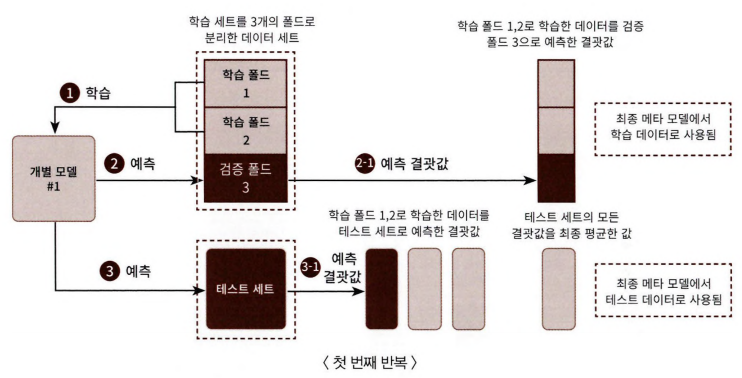

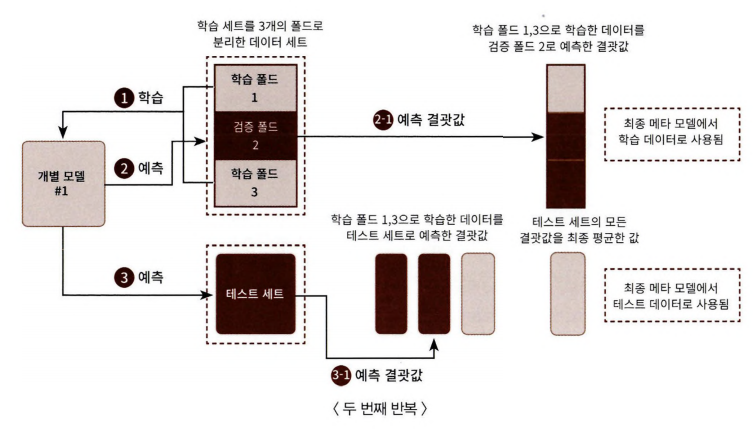

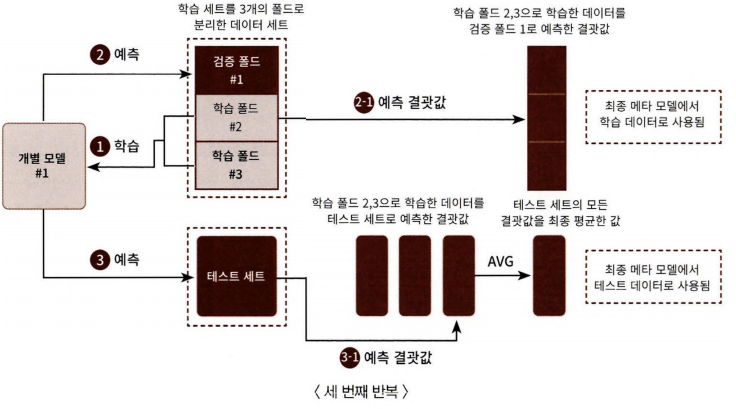

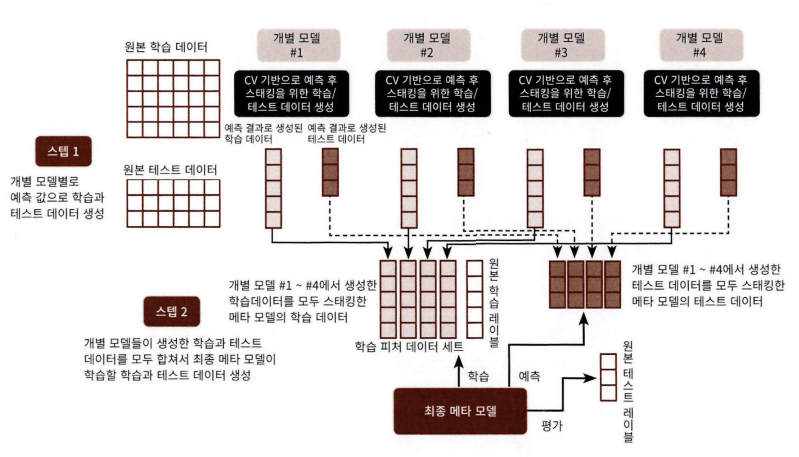

In [38]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# 개별 기반 모델에서 최종 메타 모델이 사용할 학습 및 테스트용 데이터를 생성하기 위한 함수.
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
  # 지정된 n_folds값으로 KFold 생성.
  kf = KFold(n_splits=n_folds, shuffle=False)
  # 추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화
  train_fold_pred = np.zeros((X_train_n.shape[0], 1))
  test_pred = np.zeros((X_test_n.shape[0], n_folds))
  print(model.__class__.__name__, 'model 시작')

  for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
    # 입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 세트 추출
    print('\t 폴드 세트: ', folder_counter, '시작')
    X_tr = X_train_n[train_index]
    y_tr = y_train_n[train_index]
    X_te = X_train_n[valid_index]

    # 폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행.
    model.fit(X_tr, y_tr)
    # 폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장.
    train_fold_pred[valid_index, :] = model.predict(X_te).reshape(-1,1)
    # 입력된 원본 테스트 데이터를 폴드 세트 내 학습된 기반 모델에서 예측 후 데이터 저장.
    test_pred[:, folder_counter] = model.predict(X_test_n)

  # 폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
  test_pred_mean = np.mean(test_pred, axis=1).reshape(-1,1)

  # train_fold_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean은 테스트 데이터
  return train_fold_pred, test_pred_mean

In [39]:
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test, 7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 7)

KNeighborsClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작
RandomForestClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작
DecisionTreeClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작
AdaBoostClassifier model 시작
	 폴드 세트:  0 시작
	 폴드 세트:  1 시작
	 폴드 세트:  2 시작
	 폴드 세트:  3 시작
	 폴드 세트:  4 시작
	 폴드 세트:  5 시작
	 폴드 세트:  6 시작


In [40]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)
print('원본 학습 피처 데이터 Shape:', X_train.shape, '원본 테스트 피처 Shape:', X_test.shape)
print('스태킹 학습 피처 데이터 Shape:', Stack_final_X_train.shape,
      '스태킹 테스트 피처 데이터 Shape:', Stack_final_X_test.shape)

원본 학습 피처 데이터 Shape: (455, 30) 원본 테스트 피처 Shape: (114, 30)
스태킹 학습 피처 데이터 Shape: (455, 4) 스태킹 테스트 피처 데이터 Shape: (114, 4)


In [41]:
lr_final.fit(Stack_final_X_train, y_train)
stack_final = lr_final.predict(Stack_final_X_test)

print('최종 메타 모델의 예측 정확도: {0:.4f}'.format(accuracy_score(y_test, stack_final)))

최종 메타 모델의 예측 정확도: 0.9737
